In [1]:
import torch
from torch import nn    #nn contains all the pytorch building blocks for neural network
import matplotlib.pyplot as plt

torch.__version__

'2.9.0+cpu'

1. Data (preparing and loading)

data can be anything:
 * excel sheet
 * images
 * videos (youtube has lot data)
 * text
 * DNA

machine learning is the game of two:
  1. get data in the numerical form
  2. build a model to learn the pattern in that numerical represantation

  to create this lets make some known data using linear regression formula






Linear regression

formula :- y=a+bX

In [2]:
weight=0.7
bias=0.3

start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=bias + weight*X

X[:5],y[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

Splitting data into training and testing **part**

In [3]:
train_split=int(0.8*len(X))
x_train,y_train=X[:train_split],y[:train_split]
x_test,y_test=X[train_split:],y[train_split:]
len(x_train),len(y_train),len(x_test),len(y_test)

(40, 40, 10, 10)

Visualization

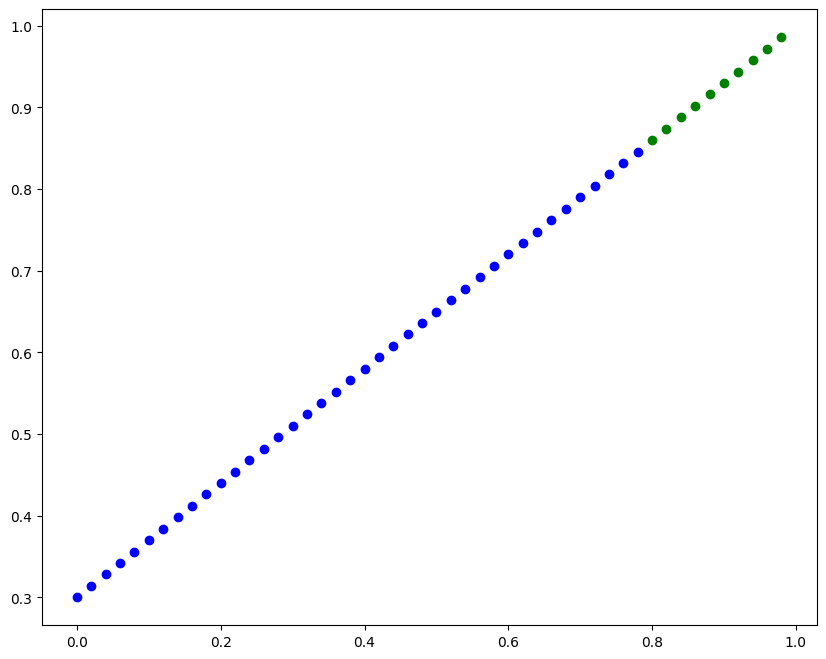

In [4]:
def plot_prediction(train_data=x_train,
                    train_label=y_train,
                    test_data=x_test,
                    test_label=y_test,
                    prediction=None):
  plt.figure(figsize=(10,8))

  # plot the training data
  plt.scatter(train_data,train_label,c='b')

  # plot the test data
  plt.scatter(test_data,test_label,c='g')

  if prediction is not None:
    plt.scatter(test_data,prediction,c='black')

  plt.show()

plot_prediction();

Buiding the first model (Linear Regression)

In [5]:
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight=nn.Parameter(torch.randn(1,
                                          requires_grad=True,
                                          dtype=torch.float))

    self.bias=nn.Parameter(torch.randn(1,
                                       requires_grad=True,
                                       dtype=torch.float))

  def forward(self,x:torch.tensor) -> torch.tensor:
      return self.weight * x + self.bias

model=LinearRegression()
for param in model.parameters():
    print(param)

Parameter containing:
tensor([1.1256], requires_grad=True)
Parameter containing:
tensor([-0.0929], requires_grad=True)


**PyTorch model building essentials**

**torch.nn** -> contains all the building block for computational graphs(essentially a series of computations exectured ina particular way)

**torch.nn.parameter** -> Stores tensors that can be used with nn.module if requires_grad=True gradients( used for updating model paramter via gradient descent) are calculated automatically this is often referred to as 'autograd'.

**toch.nn.module** -> the base classs for all neural network modules all the bulding blocks for neural network in oytirch your models should subclass nn.module. Requires a forward() method be implemented

**torch.optim** -> Contains various optimization algorithms (these tell the model parameters stored in nn.Parameter how to best change to improve gradient descent and in turn reduce the loss).

**def forward** -> All nn.Module subclasses require a forward() method, this defines the computation that will take place on the data passed to the particular nn.Module (e.g. the linear regression formula above).

In [6]:
with torch.inference_mode():
  y_pred=model(x_test)

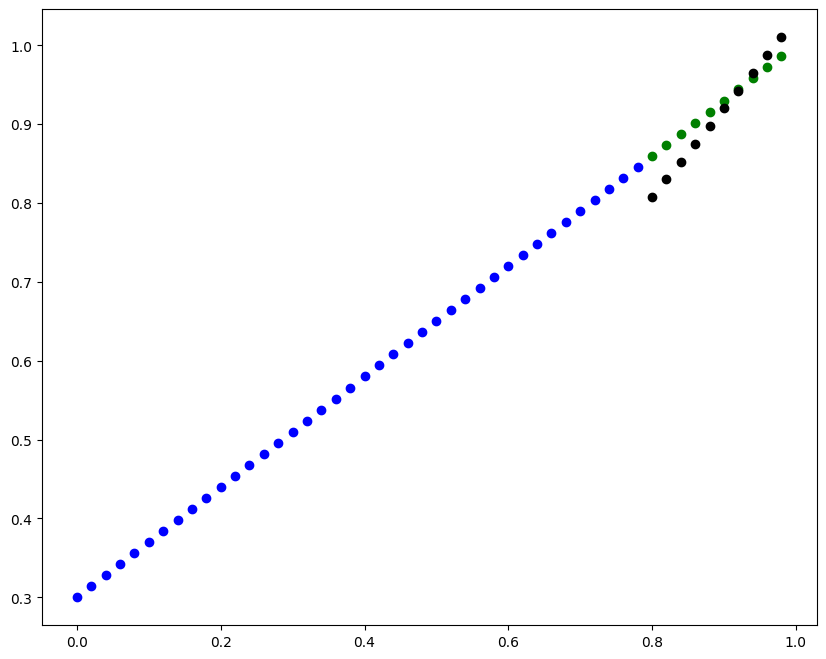

In [7]:
plot_prediction(prediction=y_pred)

**Loss function**

A loss function tells the model how wrong the prediction is
goal of training :- Minimize the Loss function
some of the loss functions(regression):
1. MSE(mean sqaured error)
2. L1loss(mean absolute error)
3. SmoothL1loss(Huber loss)

some of the loss functions(Classification):
Problem_Type	            Loss_Function
1. Binary classification	BCEWithLogitsLoss
2. Multi-clas            	CrossEntropyLoss
3. Multi-label	          BCEWithLogitsLoss
4. Class imbalance	      Focal Loss
5. OCR / Speech	          CTCLoss

**Optimizer**

1. SGD
2. Adam
3. RMSprop
4. Adagrad


An optimizer updates the model’s parameters (weights & bias)
so that loss decreases

In [8]:
loss_function = nn.L1Loss()
# loss=loss_function(y_pred,y_train)
# print(loss.item())

In [9]:
optimizer= torch.optim.SGD(model.parameters(),
                           lr=0.01)

**bUILDING A TRAINING AND TESTING LOOP**

a couple of things we need in the training loop

0. Loop through the data and do..
1. forward pass (this involves data moving through our models forward() fucntion) to make prediction on data
3. calculate the loss (compare forward pass prediction to ground truth labels)
4. loss backward- moves backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (backpropogation)
5. optimizer step use the optimizer to adjust our models parameters to try and improve the loss.

In [10]:
torch.manual_seed(42)

epochs=500  #an epoch is one loop through the data

# 0. looping thorugh data

for epoch in range(epochs):

# 1. set the model to training mode
  model.train()

#  2. forward pass
  y_pred=model(x_train)

# 3. optimizer zero grad
  optimizer.zero_grad()

# 4.perform backpropogation on the loss with respect to the parameter in the model
  loss=loss_function(y_pred,y_train)
  loss.backward()
  print(f'loss:{loss}')

# 5.step the optimizer
  optimizer.step()

###### testing
  model.eval()    # truns off different things not needed for the model for evaluating/testing (dropout/batch norm layers)

model.state_dict()

loss:0.2269291877746582
loss:0.21540816128253937
loss:0.20388713479042053
loss:0.1923661231994629
loss:0.18084509670734406
loss:0.16953767836093903
loss:0.1596575677394867
loss:0.15111422538757324
loss:0.1442127525806427
loss:0.13823255896568298
loss:0.1330554485321045
loss:0.12864001095294952
loss:0.12452027946710587
loss:0.1209758073091507
loss:0.11789820343255997
loss:0.11537794023752213
loss:0.1129249557852745
loss:0.11089739948511124
loss:0.10893265902996063
loss:0.10733121633529663
loss:0.10572977364063263
loss:0.10431772470474243
loss:0.1030774936079979
loss:0.10189306735992432
loss:0.10095079988241196
loss:0.10000856220722198
loss:0.09906630218029022
loss:0.09825223684310913
loss:0.09754623472690582
loss:0.09684022516012192
loss:0.0961342304944992
loss:0.09551003575325012
loss:0.09498008340597153
loss:0.09445013105869293
loss:0.09392015635967255
loss:0.09339021146297455
loss:0.09286025166511536
loss:0.09239841252565384
loss:0.09198571741580963
loss:0.09157304465770721
loss:0.09

OrderedDict([('weight', tensor([0.7057])), ('bias', tensor([0.2911]))])

In [11]:
loss

tensor(0.0048, grad_fn=<MeanBackward0>)

In [12]:
model.state_dict()

OrderedDict([('weight', tensor([0.7057])), ('bias', tensor([0.2911]))])

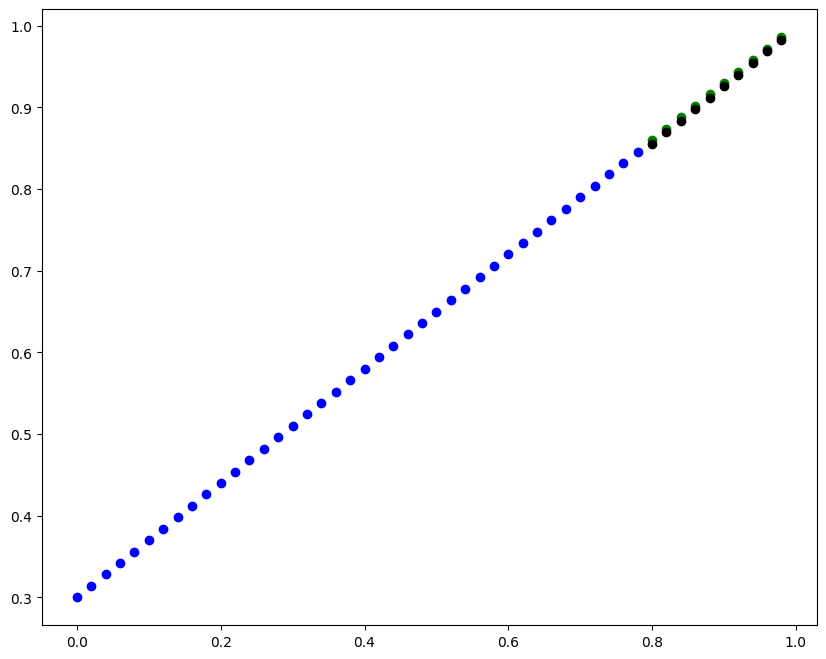

In [13]:
with torch.inference_mode():
  new_y_pred=model(x_test)

plot_prediction(prediction=new_y_pred)